In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os
import uuid
import glob
import gc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, roc_curve
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from multiprocessing import cpu_count
import random
from sklearn.utils import shuffle
import warnings
from xgboost import XGBClassifier
warnings.filterwarnings('ignore')
import joblib

In [2]:
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [3]:
CELEB_DF_COUNTS = {
    'train': {'real': 5000, 'fake': 17000},
    'val': {'real': 300, 'fake': 900},
    'test': {'real': 178, 'fake': 340}
}

WILD_DF_COUNTS = {
    'train': {'real': 8500, 'fake': 8000},
    'valid': {'real': 810, 'fake': 910},
    'test': {'real': 300, 'fake': 300}
}

FFPP_COUNTS = {
    'train': {'real': 9600, 'fake': 9600},
    'val': {'real': 1400, 'fake': 1400},
    'test': {'real': 1000, 'fake': 1000}
}

In [4]:
class DeepfakeDetector:
    def __init__(self, input_shape=(224, 224, 3)):
        self.input_shape = input_shape
        self.models = {}
        self.feature_extractors = {}
        self.scaler = StandardScaler()
        self.xgb = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42, n_estimators=100)
        self.training_histories = {}  # For storing loss curves
        
    def create_data_generator(self, file_paths, labels, batch_size=32, shuffle=True, model_type="generic"):
        """
        Creates a data generator with model-specific preprocessing.
        
        Args:
            model_type (str): Name of the model ('DenseNet201', 'EfficientNetB5', etc.)
                              to apply correct preprocessing.
        """
        def generator():
            # --- ADD THIS LINE ---
            while True:
                indices = list(range(len(file_paths)))
                if shuffle:
                    np.random.shuffle(indices)
        
                # --- INDENT THIS LOOP ---
                for i in range(0, len(indices), batch_size):
                    batch_indices = indices[i:i+batch_size]
                    batch_images, batch_labels = [], []
        
                    for idx in batch_indices:
                        try:
                            img_path = file_paths[idx]
                            image = tf.keras.preprocessing.image.load_img(
                                img_path, target_size=self.input_shape[:2]
                            )
                            image = tf.keras.preprocessing.image.img_to_array(image)

                            model_name_lower = model_type.lower()
                            
                            if model_name_lower == "convnextsmall":
                                # Uses ConvNeXt-specific preprocessing
                                image = tf.keras.applications.convnext.preprocess_input(image)
                            elif model_name_lower == "efficientnetb5":
                                # EfficientNet specific preprocessing
                                image = tf.keras.applications.efficientnet.preprocess_input(image)
                            elif model_name_lower == "densenet201":
                                image = tf.keras.applications.densenet.preprocess_input(image)
                            elif model_name_lower == "xception":
                                image = tf.keras.applications.xception.preprocess_input(image)
                            else:
                                # Default preprocessing (scales to -1, 1)
                                image = tf.keras.applications.imagenet_utils.preprocess_input(image, mode='tf')
                                
                            batch_images.append(image)
                            batch_labels.append(labels[idx])
                        except Exception as e:
                            print(f"Error loading image {img_path}: {e}")
                            continue
        
                    if batch_images:
                        yield np.array(batch_images), np.array(batch_labels)
        
        return generator


    def create_fine_tuned_model(self, model_name, num_classes=2):
        """Create and fine-tune pre-trained models"""
        if model_name == 'DenseNet201':
            base_model = tf.keras.applications.DenseNet201(
                include_top=False,
                weights='imagenet',
                input_shape=self.input_shape,
                pooling='avg'
            )
        elif model_name == 'EfficientNetB5':
            base_model = tf.keras.applications.EfficientNetB5(
                include_top=False,
                weights='imagenet',
                input_shape=self.input_shape,
                pooling='avg'
            )
        elif model_name == 'Xception':
            base_model = tf.keras.applications.Xception(
                include_top=False,
                weights='imagenet',
                input_shape=self.input_shape,
                pooling='avg'
            )
        elif model_name == 'ConvNeXtSmall':
            base_model = tf.keras.applications.ConvNeXtSmall(
                include_top=False,
                weights='imagenet',
                input_shape=self.input_shape,
                pooling='avg'
            )
        
        base_model.trainable = True
        
        # Add classification head
        inputs = base_model.input
        if model_name == 'ConvNeXtSmall':
            x = base_model.layers[-2].output
        else:
            x = base_model.output
        x = tf.keras.layers.Dense(512, activation='relu', name=f'{model_name}_dense_512')(x)
        x = tf.keras.layers.Dropout(0.5, name=f'{model_name}_dropout')(x)
        outputs = tf.keras.layers.Dense(num_classes, activation='softmax', name=f'{model_name}_output')(x)
        
        model = tf.keras.Model(inputs, outputs, name=f'{model_name}_finetuned')
        
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
            loss='categorical_crossentropy',
            metrics=['accuracy',"AUC"]
        )
        
        return model

    def create_feature_extractor(self, model_name):
        """Create feature extractor from fine-tuned model"""
        fine_tuned_model = self.models[model_name]

        # print(fine_tuned_model.layers)
        # Extract from the layer before the final classification layers
        feature_layer = fine_tuned_model.layers[-4].output  # GAP layer
            
        feature_extractor = tf.keras.Model(
            inputs=fine_tuned_model.input,
            outputs=feature_layer,
            name=f'{model_name}_feature_extractor'
        )
        
        return feature_extractor

    def fine_tune_models(self, train_files, train_labels, val_files, val_labels, 
                         steps_per_epoch, val_steps, epochs=100, batch_size=32):
        """Fine-tune all 4 models"""
        model_names = ['DenseNet201', 'EfficientNetB5', 'Xception', 'ConvNeXtSmall']
        
        for model_name in model_names:
            
            # --- ADDED CHECK TO MAKE SCRIPT RESUMABLE ---
            model_path = f'E:/Project/DFD/Model/{model_name}_best.h5'
            
            if os.path.exists(model_path):
                print(f"\nModel {model_name} already trained. Loading from disk.")
                
                # We still need to create the model object and load it
                model = self.create_fine_tuned_model(model_name)
                model.load_weights(model_path)
                
                # Add to our class objects
                self.models[model_name] = model
                self.feature_extractors[model_name] = self.create_feature_extractor(model_name)
                
                # Skip the rest of the loop (training and plotting)
                continue 
            # --- END OF ADDED CHECK ---

            # If model doesn't exist, this code will run:
            print(f"\nFine-tuning {model_name}...")
            
            train_gen = self.create_data_generator(
                train_files, 
                train_labels, 
                batch_size=batch_size, 
                shuffle=True, 
                model_type=model_name  # Pass the specific model name
            )
            val_gen = self.create_data_generator(
                val_files, 
                val_labels, 
                batch_size=batch_size, 
                shuffle=False,  # No need to shuffle validation dat
                model_type=model_name # Pass the specific model name
            )
            
            model = self.create_fine_tuned_model(model_name)
            
            callbacks = [
                tf.keras.callbacks.EarlyStopping(
                    monitor='val_accuracy',
                    patience=10,
                    restore_best_weights=True
                ),
                tf.keras.callbacks.ReduceLROnPlateau(
                    monitor='val_loss',
                    factor=0.2,
                    patience=5,
                    min_lr=1e-7
                ),
                tf.keras.callbacks.ModelCheckpoint(
                    # Use the model_path variable we defined
                    filepath=model_path,
                    monitor='val_accuracy',
                    save_best_only=True,
                    save_weights_only=False
                )
            ]
            
            history = model.fit(
                train_gen(),
                epochs=epochs,
                steps_per_epoch=steps_per_epoch,
                validation_data=val_gen(),
                validation_steps=val_steps,
                callbacks=callbacks,
                verbose=1
            )
            
            # Load best weights
            model.load_weights(model_path)
            
            self.models[model_name] = model
            
            self.feature_extractors[model_name] = self.create_feature_extractor(model_name)
            
            # loss curve for current model
            plt.figure(figsize=(10, 6))
            
            # Plot training and validation loss
            epochs_range = range(1, len(history.history['loss']) + 1)
            plt.plot(epochs_range, history.history['loss'], 'b-', label='Training', linewidth=2)
            plt.plot(epochs_range, history.history['val_loss'], 'orange', label='Validation', linewidth=2)
            
            # Customizing
            plt.title(f'{model_name} - Training and Validation Loss', fontsize=16, fontweight='bold')
            plt.xlabel('Epochs', fontsize=12)
            plt.ylabel('Loss', fontsize=12)
            plt.legend(fontsize=11)
            plt.grid(True, alpha=0.3)
            plt.xlim(0, len(history.history['loss']))
            plt.ylim(0, max(max(history.history['loss']), max(history.history['val_loss'])) * 1.1)
            
            # Saving individual plot
            plt.tight_layout()
            plt.savefig(f'E:/Project/DFD/Graphs/{model_name}_loss_curve.png', dpi=300, bbox_inches='tight')
            plt.show()
            plt.close() # free memory
            gc.collect()
            
            print(f"Loss curve saved to 'E:/Project/DFD/Graphs/{model_name}_loss_curve.png'")

    def extract_features(self, file_paths, batch_size=32):
        """Extract features from all four models"""
        model_names = ['DenseNet201', 'EfficientNetB5', 'Xception', 'ConvNeXtSmall']
        all_features = {name: [] for name in model_names}

        # Extract features from each model
        for model_name in model_names:
            for i in range(0, len(file_paths), batch_size):
                batch_paths = file_paths[i:i+batch_size]
                batch_images = []
                
                for img_path in batch_paths:
                    try:
                        image = tf.keras.preprocessing.image.load_img(
                            img_path, target_size=self.input_shape[:2]
                        )
                        image = tf.keras.preprocessing.image.img_to_array(image)
                        
                        model_name_lower = model_name.lower()
                        
                        if model_name_lower == "convnextsmall":
                            image = tf.keras.applications.convnext.preprocess_input(image)
                        elif model_name_lower == "efficientnetb5":
                            image = tf.keras.applications.efficientnet.preprocess_input(image)
                        elif model_name_lower == "densenet201":
                            image = tf.keras.applications.densenet.preprocess_input(image)
                        elif model_name_lower == "xception":
                            image = tf.keras.applications.xception.preprocess_input(image)
                        else:
                            image = tf.keras.applications.imagenet_utils.preprocess_input(image, mode='tf')
                        
                        batch_images.append(image)
                    except Exception as e:
                        print(f"Error loading {img_path}: {e}")
                        # Add dummy image if loading fails
                        batch_images.append(np.zeros(self.input_shape))
                
                if batch_images:
                    batch_images = np.array(batch_images)
                    
                    features = self.feature_extractors[model_name].predict(
                        batch_images, verbose=0
                    )
                    all_features[model_name].extend(features)
        
        # Convert to numpy arrays and stack
        densenet_features = np.array(all_features['DenseNet201'])
        efficientnet_features = np.array(all_features['EfficientNetB5'])
        xception_features = np.array(all_features['Xception'])
        convnextsmall_features = np.array(all_features['ConvNeXtSmall'])
        
        stacked_features = np.concatenate([
            densenet_features,
            efficientnet_features,
            xception_features,
            convnextsmall_features
        ], axis=1)
        
        return stacked_features

    def relief_f_score(self, X, y, k=10):
        """ReliefF feature selection algorithm"""
        n_samples, n_features = X.shape
        feature_scores = np.zeros(n_features)
        
        for i in range(n_samples):
            # Find k nearest neighbors
            distances = np.sum((X - X[i]) ** 2, axis=1)
            nearest_indices = np.argsort(distances)[1:k+1]  # Exclude self
            
            # Separate hits (same class) and misses (different class)
            hits = [idx for idx in nearest_indices if y[idx] == y[i]]
            misses = [idx for idx in nearest_indices if y[idx] != y[i]]
            
            # Update feature scores
            for j in range(n_features):
                if hits:
                    hit_diff = np.mean([abs(X[i, j] - X[idx, j]) for idx in hits])
                    feature_scores[j] -= hit_diff
                
                if misses:
                    miss_diff = np.mean([abs(X[i, j] - X[idx, j]) for idx in misses])
                    feature_scores[j] += miss_diff
        
        return (feature_scores - np.min(feature_scores)) / (np.max(feature_scores) - np.min(feature_scores))

    def mrmr_score(self, X, y, selected_features=None):
        """Minimum Redundancy Maximum Relevance score"""
        if selected_features is None:
            selected_features = []
        
        mi_scores = mutual_info_classif(X, y)
        
        if not selected_features:
            return mi_scores
        
        n_features = X.shape[1]
        mrmr_scores = np.zeros(n_features)
        
        for i in range(n_features):
            if i in selected_features:
                mrmr_scores[i] = -np.inf
                continue
                
            # Relevance (MI with target)
            relevance = mi_scores[i]
            
            # Redundancy (average MI with selected features)
            if selected_features:
                redundancy = np.mean([
                    mutual_info_classif(X[:, [i, j]], y)[0] 
                    for j in selected_features
                ])
            else:
                redundancy = 0
            
            mrmr_scores[i] = relevance - redundancy
        
        return mrmr_scores

    def feature_selection(self, X_train, y_train, X_val, y_val, tau=0.3, alpha=0.1, beta=0.1, max_iterations=1000):
        """Combined feature selection with ReliefF, MI, mRMR and inclusion-exclusion"""
        print("Starting feature selection...")
        
        # Step 1: Calculate individual scores
        relief_scores = self.relief_f_score(X_train, y_train)
        mi_scores = mutual_info_classif(X_train, y_train)
        mrmr_scores = self.mrmr_score(X_train, y_train)
        
        # Normalize scores
        relief_scores = (relief_scores - np.min(relief_scores)) / (np.max(relief_scores) - np.min(relief_scores))
        mi_scores = (mi_scores - np.min(mi_scores)) / (np.max(mi_scores) - np.min(mi_scores))
        mrmr_scores = (mrmr_scores - np.min(mrmr_scores)) / (np.max(mrmr_scores) - np.min(mrmr_scores))
        
        # Step 2: Combine scores
        combined_scores = (relief_scores + mi_scores + mrmr_scores) / 3
        
        # Step 3: Initial feature selection (top tau% features)
        n_features = len(combined_scores)
        n_initial = int(tau * n_features)
        initial_indices = np.argsort(combined_scores)[-n_initial:]
        
        # Step 4: Inclusion-exclusion optimization
        best_features = initial_indices.copy()
        best_fitness = self.calculate_fitness(X_val, y_val, best_features)
        
        for iteration in range(max_iterations):
            # Create new candidate solution
            current_features = best_features.copy()
            
            # Exclusion: randomly remove some features
            n_exclude = max(1, int(alpha * len(current_features)))
            if len(current_features) > n_exclude:
                exclude_indices = np.random.choice(
                    len(current_features), n_exclude, replace=False
                )
                current_features = np.delete(current_features, exclude_indices)
            
            # Inclusion: add some features from remaining
            remaining_features = np.setdiff1d(np.arange(n_features), current_features)
            if len(remaining_features) > 0:
                n_include = min(int(beta * n_features), len(remaining_features))
                # Select top features from remaining based on combined scores
                remaining_scores = combined_scores[remaining_features]
                include_indices = remaining_features[np.argsort(remaining_scores)[-n_include:]]
                current_features = np.concatenate([current_features, include_indices])
            
            current_fitness = self.calculate_fitness(X_val, y_val, current_features)
            
            # Update best solution if improved
            if current_fitness > best_fitness:
                best_features = current_features.copy()
                best_fitness = current_fitness
                print(f"Iteration {iteration}: New best fitness = {best_fitness:.4f}, Features = {len(best_features)}")
        
        print(f"Feature selection completed. Selected {len(best_features)} features out of {n_features}")
        return best_features

    def calculate_fitness(self, X_val, y_val, feature_indices, weight=0.9):
        """Calculate fitness function for feature selection"""
        if len(feature_indices) == 0:
            return 0
        
        X_selected = X_val[:, feature_indices]
        
        temp_xgb = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42, n_estimators=100)
        temp_xgb.fit(self.scaler.fit_transform(X_selected), y_val)
        accuracy = temp_xgb.score(self.scaler.transform(X_selected), y_val)
        
        # Fitness combines accuracy and feature reduction
        feature_ratio = len(feature_indices) / X_val.shape[1]
        fitness = weight * accuracy + (1 - weight) * (1 - feature_ratio)
        
        return fitness

    def train_xgb(self, X_train, y_train, selected_features):
        """Train XGBoost classifier on selected features"""
        X_selected = X_train[:, selected_features]
        X_scaled = self.scaler.fit_transform(X_selected)
        self.xgb.fit(X_scaled, y_train)

    def predict(self, X_test, selected_features):
        """Make predictions using trained XGBoost classifier"""
        X_selected = X_test[:, selected_features]
        X_scaled = self.scaler.transform(X_selected)
        predictions = self.xgb.predict(X_scaled)
        probabilities = self.xgb.predict_proba(X_scaled)
        return predictions, probabilities

In [7]:
def prepare_dataset(dataset_name, base_path):
    """Prepare dataset paths and labels"""
    if dataset_name == 'FFPP':
        fake_paths = sorted(glob.glob(os.path.join(base_path, "fake", "Deepfakes", "*", "*.png")))
        real_paths = sorted(glob.glob(os.path.join(base_path, "real", "*", "*.png")))
        
        np.random.shuffle(fake_paths)
        np.random.shuffle(real_paths)
        
        train_paths = (
            real_paths[:FFPP_COUNTS['train']['real']] +
            fake_paths[:FFPP_COUNTS['train']['fake']]
        )
        val_paths = (
            real_paths[FFPP_COUNTS['train']['real']:FFPP_COUNTS['train']['real']+FFPP_COUNTS['val']['real']] +
            fake_paths[FFPP_COUNTS['train']['fake']:FFPP_COUNTS['train']['fake']+FFPP_COUNTS['val']['fake']]
        )
        test_paths = (
            real_paths[-FFPP_COUNTS['test']['real']:] +
            fake_paths[-FFPP_COUNTS['test']['fake']:]
        )
        
        train_labels = [0] * FFPP_COUNTS['train']['real'] + [1] * FFPP_COUNTS['train']['fake']
        val_labels = [0] * FFPP_COUNTS['val']['real'] + [1] * FFPP_COUNTS['val']['fake']
        test_labels = [0] * FFPP_COUNTS['test']['real'] + [1] * FFPP_COUNTS['test']['fake']
        
    elif dataset_name == 'CelebDF':
        train_real = sorted(glob.glob(os.path.join(base_path, "train", "real", "*.jpg")))
        train_fake = sorted(glob.glob(os.path.join(base_path, "train", "fake", "*.jpg")))
        val_real = sorted(glob.glob(os.path.join(base_path, "val", "real", "*.jpg")))
        val_fake = sorted(glob.glob(os.path.join(base_path, "val", "fake", "*.jpg")))
        test_real = sorted(glob.glob(os.path.join(base_path, "test", "real", "*.jpg")))
        test_fake = sorted(glob.glob(os.path.join(base_path, "test", "fake", "*.jpg")))

        for paths in [train_real, train_fake, val_real, val_fake, test_real, test_fake]:
            np.random.shuffle(paths)

        train_real = train_real[:CELEB_DF_COUNTS['train']['real']]
        train_fake = train_fake[:CELEB_DF_COUNTS['train']['fake']]
        val_real = val_real[:CELEB_DF_COUNTS['val']['real']]
        val_fake = val_fake[:CELEB_DF_COUNTS['val']['fake']]
        test_real = test_real[:CELEB_DF_COUNTS['test']['real']]
        test_fake = test_fake[:CELEB_DF_COUNTS['test']['fake']]
        
        train_paths = train_real + train_fake
        val_paths = val_real + val_fake
        test_paths = test_real + test_fake
        
        train_labels = [0] * len(train_real) + [1] * len(train_fake)
        val_labels = [0] * len(val_real) + [1] * len(val_fake)
        test_labels = [0] * len(test_real) + [1] * len(test_fake)
    elif dataset_name == 'Wild-DeepFake':
        train_real = sorted(glob.glob(os.path.join(base_path, "train", "real", "*.png")))
        train_fake = sorted(glob.glob(os.path.join(base_path, "train", "fake", "*.png")))
        valid_real = sorted(glob.glob(os.path.join(base_path, "valid", "real", "*.png")))
        valid_fake = sorted(glob.glob(os.path.join(base_path, "valid", "fake", "*.png")))
        test_real = sorted(glob.glob(os.path.join(base_path, "test", "real", "*.png")))
        test_fake = sorted(glob.glob(os.path.join(base_path, "test", "fake", "*.png")))
    
        for paths in [train_real, train_fake, valid_real, valid_fake, test_real, test_fake]:
            np.random.shuffle(paths)
    
        train_real = train_real[:WILD_DF_COUNTS['train']['real']]
        train_fake = train_fake[:WILD_DF_COUNTS['train']['fake']]
        valid_real = valid_real[:WILD_DF_COUNTS['valid']['real']]
        valid_fake = valid_fake[:WILD_DF_COUNTS['valid']['fake']]
        test_real = test_real[:WILD_DF_COUNTS['test']['real']]
        test_fake = test_fake[:WILD_DF_COUNTS['test']['fake']]
            
        train_paths = train_real + train_fake
        val_paths = valid_real + valid_fake
        test_paths = test_real + test_fake
            
        train_labels = [0] * len(train_real) + [1] * len(train_fake)
        val_labels = [0] * len(valid_real) + [1] * len(valid_fake)
        test_labels = [0] * len(test_real) + [1] * len(test_fake)
    
    train_paths, train_labels = shuffle(train_paths, train_labels, random_state=42)
    val_paths, val_labels = shuffle(val_paths, val_labels, random_state=42)
    test_paths, test_labels = shuffle(test_paths, test_labels, random_state=42)
    
    return {
        'train': (train_paths, train_labels),
        'val': (val_paths, val_labels),
        'test': (test_paths, test_labels)
    }

def run_experiment(train_dataset, test_dataset, train_path, test_path):
    """Run complete experiment (intra-dataset or inter-dataset)"""
    print(f"\n{'='*50}")
    print(f"Running experiment: {train_dataset} -> {test_dataset}")
    print(f"{'='*50}")
    
    detector = DeepfakeDetector()
    
    train_data = prepare_dataset(train_dataset, train_path)
    test_data = prepare_dataset(test_dataset, test_path)
    
    # Convert labels to categorical for fine-tuning
    train_labels_cat = tf.keras.utils.to_categorical(train_data['train'][1], 2)
    val_labels_cat = tf.keras.utils.to_categorical(train_data['val'][1], 2)
    
    # Define batch size once
    BATCH_SIZE = 16
    
    steps_per_epoch = len(train_data['train'][0]) // BATCH_SIZE
    val_steps = len(train_data['val'][0]) // BATCH_SIZE
    
    # Pass raw data to fine_tune_models ---
    detector.fine_tune_models(
        train_data['train'][0], train_labels_cat,  # Training files and labels
        train_data['val'][0], val_labels_cat,    # Validation files and labels
        steps_per_epoch, val_steps,
        epochs=100,
        batch_size=BATCH_SIZE  # Pass batch size
    )
    
    print("\nExtracting features...")
    train_features = detector.extract_features(train_data['train'][0])
    val_features = detector.extract_features(train_data['val'][0])
    test_features = detector.extract_features(test_data['test'][0])
    
    print(f"Feature dimensions: {train_features.shape[1]}")
    
    # Feature selection
    selected_features = detector.feature_selection(
        train_features, train_data['train'][1],
        val_features, train_data['val'][1]
    )
    
    print(f"\nTraining XGBoost classifier with {len(selected_features)} selected features...")
    detector.train_xgb(train_features, train_data['train'][1], selected_features)
    
    print("Saving final models to disk...")
    model_save_path = "E:/Project/DFD/Model/"

    # Save the XGBoost "brain"
    joblib.dump(detector.xgb, os.path.join(model_save_path, 'xgb_model.joblib'))

    # Save the scaler
    joblib.dump(detector.scaler, os.path.join(model_save_path, 'scaler.joblib'))

    # Save the all-important feature list
    np.save(os.path.join(model_save_path, 'selected_features.npy'), selected_features)

    print(f"--- Final models saved to {model_save_path} ---")
    # --- END OF ADDED CODE ---

    # Evaluate on test set
    test_predictions, test_probabilities = detector.predict(test_features, selected_features)

    # Evaluate on test set
    test_predictions, test_probabilities = detector.predict(test_features, selected_features)
    
    test_accuracy = accuracy_score(test_data['test'][1], test_predictions)
    test_auc = roc_auc_score(test_data['test'][1], test_probabilities[:, 1])
    
    print(f"\nResults for {train_dataset} -> {test_dataset}:")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test AUC: {test_auc:.4f}")
    
    # More Evaluation Metrics
    precision = precision_score(test_data['test'][1], test_predictions)
    recall = recall_score(test_data['test'][1], test_predictions)
    
    print(f"Test Precision: {precision:.4f}")
    print(f"Test Recall: {recall:.4f}")
    
    print(f"Original features: {train_features.shape[1]}")
    print(f"Selected features: {len(selected_features)}")
    print(f"Feature reduction: {(1 - len(selected_features)/train_features.shape[1])*100:.2f}%")
    
    # Confusion matrix
    cm = confusion_matrix(test_data['test'][1], test_predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title(f'Confusion Matrix: {train_dataset} -> {test_dataset}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'E:\Project\DFD\Graphs\confusion_matrix_{train_dataset}-{test_dataset}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # roc curve
    fpr, tpr, threshold = roc_curve(test_data['test'][1], test_probabilities[:, 1])
    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % test_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.title('ROC Curve of XGBoost')
    plt.show()

    # classification report
    print("\nClassification Report:")
    cf = classification_report(test_data['test'][1], test_predictions, output_dict=True)
    cf = pd.DataFrame(cf).transpose()
    cf = cf.drop(labels=['accuracy'],errors='ignore')
    cf_plot = cf[['precision', 'recall', 'f1-score']]
    plt.figure(figsize=(8, 6))
    sns.heatmap(cf_plot, annot=True, fmt='.2f', cmap='Greens',linewidths=.5)
    plt.xlabel('Metrics')
    plt.title('Classification Report')
    plt.show()
    
    return {
        'accuracy': test_accuracy,
        'auc': test_auc,
        'selected_features': len(selected_features),
        'original_features': train_features.shape[1]
    }, detector, selected_features


In [9]:
from pprint import pprint as pp

if __name__ == "__main__":
    celebdf_path = r"E:\Project\DFD\CelebDF"
    ffpp_path = r"E:\Project\DFD\FFPP"
    wilddf_path = r"E:\Project\DFD\Wild-DeepFake"
    
    try:
        result, trained_detector, selected_features_list = run_experiment('CelebDF', 'CelebDF', celebdf_path, celebdf_path)

        print('\n\n')
        pp(result)

    except Exception as e:
        print(f"Error in experiment: {e}")
        import traceback
        traceback.print_exc()


Running experiment: CelebDF -> CelebDF

Model DenseNet201 already trained. Loading from disk.


KeyboardInterrupt: 

In [6]:
import os
import numpy as np
import tensorflow as tf
import joblib
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

# --- 1. DEFINE THE CLASS (Required to rebuild the model structure) ---
class DeepfakeDetector:
    def __init__(self, input_shape=(224, 224, 3)):
        self.input_shape = input_shape
        self.models = {}
        self.feature_extractors = {}
        self.scaler = StandardScaler()
        # Initialize empty XGB, will be overwritten by load
        self.xgb = XGBClassifier() 
        
    def create_fine_tuned_model(self, model_name, num_classes=2):
        """Re-creates the model architecture to load weights into"""
        if model_name == 'DenseNet201':
            base_model = tf.keras.applications.DenseNet201(include_top=False, weights=None, input_shape=self.input_shape, pooling='avg')
        elif model_name == 'EfficientNetB5':
            base_model = tf.keras.applications.EfficientNetB5(include_top=False, weights=None, input_shape=self.input_shape, pooling='avg')
        elif model_name == 'Xception':
            base_model = tf.keras.applications.Xception(include_top=False, weights=None, input_shape=self.input_shape, pooling='avg')
        elif model_name == 'ConvNeXtSmall':
            base_model = tf.keras.applications.ConvNeXtSmall(include_top=False, weights=None, input_shape=self.input_shape, pooling='avg')
        
        inputs = base_model.input
        if model_name == 'ConvNeXtSmall':
            x = base_model.layers[-2].output
        else:
            x = base_model.output
            
        x = tf.keras.layers.Dense(512, activation='relu', name=f'{model_name}_dense_512')(x)
        x = tf.keras.layers.Dropout(0.5, name=f'{model_name}_dropout')(x)
        outputs = tf.keras.layers.Dense(num_classes, activation='softmax', name=f'{model_name}_output')(x)
        
        model = tf.keras.Model(inputs, outputs, name=f'{model_name}_finetuned')
        # Compile with string 'AUC' to avoid the previous JSON error
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', 'AUC'])
        return model

    def create_feature_extractor(self, model_name):
        """Re-creates the feature extractor"""
        fine_tuned_model = self.models[model_name]
        feature_layer = fine_tuned_model.layers[-4].output
        return tf.keras.Model(inputs=fine_tuned_model.input, outputs=feature_layer)

    def extract_features(self, file_paths):
        """Extracts features from images using all 4 loaded models"""
        model_names = ['DenseNet201', 'EfficientNetB5', 'Xception', 'ConvNeXtSmall']
        all_features = {name: [] for name in model_names}

        for model_name in model_names:
            batch_images = []
            for img_path in file_paths:
                try:
                    image = tf.keras.preprocessing.image.load_img(img_path, target_size=self.input_shape[:2])
                    image = tf.keras.preprocessing.image.img_to_array(image)
                    
                    # Apply correct preprocessing
                    model_name_lower = model_name.lower()
                    if model_name_lower == "convnextsmall":
                        image = tf.keras.applications.convnext.preprocess_input(image)
                    elif model_name_lower == "efficientnetb5":
                        image = tf.keras.applications.efficientnet.preprocess_input(image)
                    elif model_name_lower == "densenet201":
                        image = tf.keras.applications.densenet.preprocess_input(image)
                    elif model_name_lower == "xception":
                        image = tf.keras.applications.xception.preprocess_input(image)
                    else:
                        image = tf.keras.applications.imagenet_utils.preprocess_input(image, mode='tf')
                    
                    batch_images.append(image)
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")
                    batch_images.append(np.zeros(self.input_shape))
            
            if batch_images:
                features = self.feature_extractors[model_name].predict(np.array(batch_images), verbose=0)
                all_features[model_name].extend(features)
        
        # Stack features
        return np.concatenate([np.array(all_features[name]) for name in model_names], axis=1)

    def predict(self, X_test, selected_features):
        """Predicts using the loaded XGBoost model"""
        X_selected = X_test[:, selected_features]
        X_scaled = self.scaler.transform(X_selected)
        return self.xgb.predict(X_scaled), self.xgb.predict_proba(X_scaled)

# --- 2. LOAD EVERYTHING FROM DISK ---

# 1. Setup Paths
model_dir = r"E:\Project\DFD\Model" # <--- VERIFY THIS PATH
model_names = ['DenseNet201', 'EfficientNetB5', 'Xception', 'ConvNeXtSmall']

# 2. Initialize the empty detector
print("Initializing detector...")
trained_detector = DeepfakeDetector()

# 3. Load the 4 CNN Models (The "Eyes")
print("Loading CNN models...")
for name in model_names:
    weights_path = os.path.join(model_dir, f'{name}_best.h5')
    if os.path.exists(weights_path):
        print(f" - Loading {name}...")
        trained_detector.models[name] = trained_detector.create_fine_tuned_model(name)
        trained_detector.models[name].load_weights(weights_path)
        trained_detector.feature_extractors[name] = trained_detector.create_feature_extractor(name)
    else:
        raise FileNotFoundError(f"Critical model file missing: {weights_path}")

# 4. Load the XGBoost, Scaler, and Feature List (The "Brain")
print("Loading Classifier and Feature List...")
try:
    trained_detector.xgb = joblib.load(os.path.join(model_dir, 'xgb_model.joblib'))
    trained_detector.scaler = joblib.load(os.path.join(model_dir, 'scaler.joblib'))
    selected_features_list = np.load(os.path.join(model_dir, 'selected_features.npy'))
    print("✅ Model successfully loaded!")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("You must run the training script ONE LAST TIME to generate these .joblib and .npy files.")
    raise

# --- 3. PREDICT FUNCTION ---

def run_prediction(image_path):
    print(f"\nAnalyzing: {image_path}")
    if not os.path.exists(image_path):
        print("❌ Error: Image file not found.")
        return

    # 1. Extract
    features = trained_detector.extract_features([image_path])
    
    # 2. Predict
    pred, prob = trained_detector.predict(features, selected_features_list)
    
    # 3. Result
    cls = pred[0]
    conf = prob[0]
    
    label = "FAKE" if cls == 1 else "REAL"
    confidence = conf[cls] * 100
    
    print(f"{'-'*30}")
    print(f"RESULT: {label}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"{'-'*30}")

# --- 4. RUN IT ---

# Replace with your image path
my_image = r"E:\facefusion\output\3.jpg"

run_prediction(my_image)

Initializing detector...
Loading CNN models...
 - Loading DenseNet201...
 - Loading EfficientNetB5...
 - Loading Xception...
 - Loading ConvNeXtSmall...
Loading Classifier and Feature List...
✅ Model successfully loaded!

Analyzing: E:\facefusion\output\3.jpg
------------------------------
RESULT: FAKE
Confidence: 64.31%
------------------------------


In [7]:
import os
import numpy as np
import tensorflow as tf
import joblib
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

# --- 1. DEFINE THE CLASS ---
class DeepfakeDetector:
    def __init__(self, input_shape=(224, 224, 3)):
        self.input_shape = input_shape
        self.models = {}
        self.feature_extractors = {}
        self.scaler = StandardScaler()
        self.xgb = XGBClassifier() 
        
    def create_fine_tuned_model(self, model_name, num_classes=2):
        """Re-creates the model architecture"""
        if model_name == 'DenseNet201':
            base_model = tf.keras.applications.DenseNet201(include_top=False, weights=None, input_shape=self.input_shape, pooling='avg')
        elif model_name == 'EfficientNetB5':
            base_model = tf.keras.applications.EfficientNetB5(include_top=False, weights=None, input_shape=self.input_shape, pooling='avg')
        elif model_name == 'Xception':
            base_model = tf.keras.applications.Xception(include_top=False, weights=None, input_shape=self.input_shape, pooling='avg')
        elif model_name == 'ConvNeXtSmall':
            base_model = tf.keras.applications.ConvNeXtSmall(include_top=False, weights=None, input_shape=self.input_shape, pooling='avg')
        
        inputs = base_model.input
        if model_name == 'ConvNeXtSmall':
            x = base_model.layers[-2].output
        else:
            x = base_model.output
            
        x = tf.keras.layers.Dense(512, activation='relu', name=f'{model_name}_dense_512')(x)
        x = tf.keras.layers.Dropout(0.5, name=f'{model_name}_dropout')(x)
        outputs = tf.keras.layers.Dense(num_classes, activation='softmax', name=f'{model_name}_output')(x)
        
        model = tf.keras.Model(inputs, outputs, name=f'{model_name}_finetuned')
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', 'AUC'])
        return model

    def create_feature_extractor(self, model_name):
        """Re-creates the feature extractor"""
        fine_tuned_model = self.models[model_name]
        feature_layer = fine_tuned_model.layers[-4].output
        return tf.keras.Model(inputs=fine_tuned_model.input, outputs=feature_layer)

    def extract_features(self, file_paths):
        """Extracts features and prints debug info for each model"""
        model_names = ['DenseNet201', 'EfficientNetB5', 'Xception', 'ConvNeXtSmall']
        all_features = {name: [] for name in model_names}

        print("\n--- INDIVIDUAL MODEL FEATURE EXTRACTION ---")

        for model_name in model_names:
            batch_images = []
            for img_path in file_paths:
                try:
                    image = tf.keras.preprocessing.image.load_img(img_path, target_size=self.input_shape[:2])
                    image = tf.keras.preprocessing.image.img_to_array(image)
                    
                    # Apply correct preprocessing
                    model_name_lower = model_name.lower()
                    if model_name_lower == "convnextsmall":
                        image = tf.keras.applications.convnext.preprocess_input(image)
                    elif model_name_lower == "efficientnetb5":
                        image = tf.keras.applications.efficientnet.preprocess_input(image)
                    elif model_name_lower == "densenet201":
                        image = tf.keras.applications.densenet.preprocess_input(image)
                    elif model_name_lower == "xception":
                        image = tf.keras.applications.xception.preprocess_input(image)
                    else:
                        image = tf.keras.applications.imagenet_utils.preprocess_input(image, mode='tf')
                    
                    batch_images.append(image)
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")
                    batch_images.append(np.zeros(self.input_shape))
            
            if batch_images:
                # Extract features for this batch
                features = self.feature_extractors[model_name].predict(np.array(batch_images), verbose=0)
                all_features[model_name].extend(features)
                
                # --- DEBUG PRINTING ---
                feat_vector = features[0]
                print(f"[{model_name}] Output Shape: {feat_vector.shape}")
                print(f"   -> First 5 features: {feat_vector[:5]}")
                print(f"   -> Mean value: {np.mean(feat_vector):.4f}")
                print(f"   -> Max value: {np.max(feat_vector):.4f}")
        
        # Stack features
        combined_features = np.concatenate([np.array(all_features[name]) for name in model_names], axis=1)
        print(f"--- COMBINED FEATURE VECTOR SHAPE: {combined_features.shape} ---")
        return combined_features

    def predict(self, X_test, selected_features):
        """Predicts using the loaded XGBoost model"""
        # Select specific features
        X_selected = X_test[:, selected_features]
        
        # Scale features
        X_scaled = self.scaler.transform(X_selected)
        
        return self.xgb.predict(X_scaled), self.xgb.predict_proba(X_scaled), X_scaled

# --- 2. LOAD EVERYTHING FROM DISK ---

# 1. Setup Paths
model_dir = r"E:\Project\DFD\Model" 
model_names = ['DenseNet201', 'EfficientNetB5', 'Xception', 'ConvNeXtSmall']

# 2. Initialize
print("Initializing detector...")
trained_detector = DeepfakeDetector()

# 3. Load CNNs
print("Loading CNN models...")
for name in model_names:
    weights_path = os.path.join(model_dir, f'{name}_best.h5')
    if os.path.exists(weights_path):
        # print(f" - Loading {name}...") # Commented out to reduce clutter
        trained_detector.models[name] = trained_detector.create_fine_tuned_model(name)
        trained_detector.models[name].load_weights(weights_path)
        trained_detector.feature_extractors[name] = trained_detector.create_feature_extractor(name)
    else:
        raise FileNotFoundError(f"Critical model file missing: {weights_path}")

# 4. Load XGBoost Brain
print("Loading Classifier and Feature List...")
try:
    trained_detector.xgb = joblib.load(os.path.join(model_dir, 'xgb_model.joblib'))
    trained_detector.scaler = joblib.load(os.path.join(model_dir, 'scaler.joblib'))
    selected_features_list = np.load(os.path.join(model_dir, 'selected_features.npy'))
    print("✅ Models loaded.")
except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    raise

# --- 3. PREDICT FUNCTION ---

def run_prediction(image_path):
    print(f"\nAnalyzing: {image_path}")
    if not os.path.exists(image_path):
        print("❌ Error: Image file not found.")
        return

    # 1. Extract (prints individual model outputs inside)
    features = trained_detector.extract_features([image_path])
    
    # 2. Predict (returns scaled features too)
    pred, prob, final_input_vector = trained_detector.predict(features, selected_features_list)
    
    # --- DEBUG PRINT: XGBOOST INPUT ---
    print("\n--- FINAL INPUT TO XGBOOST ---")
    print(f"Total Features Selected: {final_input_vector.shape[1]}")
    print(f"First 10 Scaled Values passed to XGBoost:")
    print(final_input_vector[0][:10])
    print(f"Mean of Input Vector: {np.mean(final_input_vector):.4f}")
    # ----------------------------------

    # 3. Result
    cls = pred[0]
    conf = prob[0]
    
    label = "FAKE" if cls == 1 else "REAL"
    confidence = conf[cls] * 100
    
    print(f"\n{'-'*30}")
    print(f"RESULT: {label}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"{'-'*30}")

# --- 4. RUN IT ---

# Replace with your image path
my_image = r"E:\facefusion\output\1.jpg"

run_prediction(my_image)

Initializing detector...
Loading CNN models...
Loading Classifier and Feature List...
✅ Models loaded.

Analyzing: E:\facefusion\output\1.jpg

--- INDIVIDUAL MODEL FEATURE EXTRACTION ---
[DenseNet201] Output Shape: (1920,)
   -> First 5 features: [1.8814547e-04 4.4131837e-05 5.1621225e-04 2.5706252e-04 0.0000000e+00]
   -> Mean value: 0.2747
   -> Max value: 6.3317
[EfficientNetB5] Output Shape: (2048,)
   -> First 5 features: [-0.12083868  0.08699836 -0.1921438  -0.06434099 -0.14352798]
   -> Mean value: -0.0702
   -> Max value: 1.4538
[Xception] Output Shape: (2048,)
   -> First 5 features: [0.         0.         0.         0.         0.00500605]
   -> Mean value: 0.0521
   -> Max value: 2.1502
[ConvNeXtSmall] Output Shape: (768,)
   -> First 5 features: [ 0.79121757  0.63098466 -0.89549744 -1.7811525   0.33141187]
   -> Mean value: -0.0256
   -> Max value: 8.0614
--- COMBINED FEATURE VECTOR SHAPE: (1, 6784) ---

--- FINAL INPUT TO XGBOOST ---
Total Features Selected: 2035
First 10 S

Generating Heatmaps for: E:\facefusion\output\1.jpg...


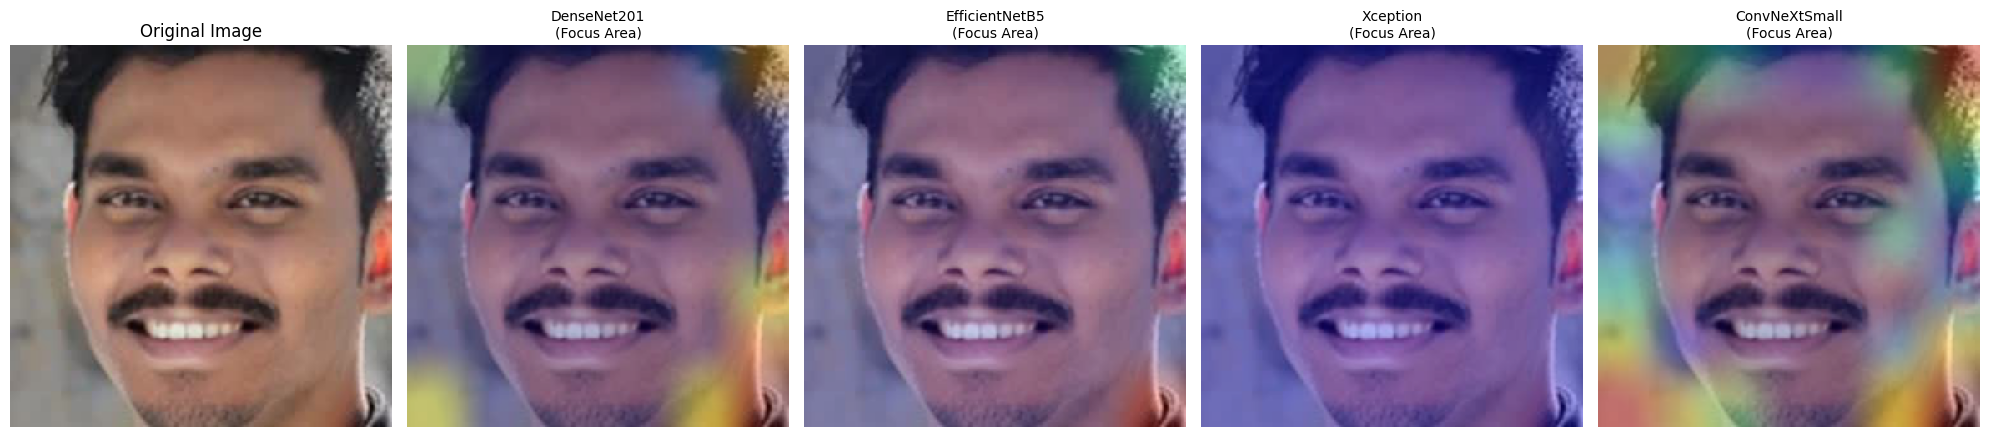

In [9]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2

def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    """
    Generates a Grad-CAM heatmap for a specific model and image.
    """
    # 1. Create a model that maps the input image to the activations
    #    of the last conv layer as well as the output predictions
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 2. Compute the gradient of the top predicted class for our input image
    #    with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 3. This is the gradient of the output neuron (top predicted or chosen)
    #    with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 4. This is a vector where each entry is the mean intensity of the gradient
    #    over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. We multiply each channel in the feature map array
    #    by "how important this channel is" with regard to the top predicted class
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 6. For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def find_target_layer(model):
    """
    Automatically attempts to find the last 4D (spatial) convolutional layer.
    """
    for layer in reversed(model.layers):
        # We are looking for a layer with 4 dimensions (Batch, Height, Width, Channels)
        if len(layer.output_shape) == 4:
            return layer.name
    raise ValueError("Could not find a suitable 4D layer for Grad-CAM.")

def visualize_what_models_see(image_path, detector):
    """
    Runs Grad-CAM on all 4 models and plots the results.
    """
    print(f"Generating Heatmaps for: {image_path}...")
    
    # Prepare the figure
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    
    # 1. Load and Plot Original Image
    original_img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(original_img)
    
    axes[0].imshow(original_img)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    # 2. Loop through each model
    model_names = ['DenseNet201', 'EfficientNetB5', 'Xception', 'ConvNeXtSmall']
    
    for i, model_name in enumerate(model_names):
        ax = axes[i+1]
        
        if model_name not in detector.models:
            ax.text(0.5, 0.5, "Model Not Loaded", ha='center')
            continue

        model = detector.models[model_name]
        
        # A. Preprocess specifically for this model
        # (We must repeat the preprocessing logic here to be accurate)
        model_input = img_array.copy()
        model_name_lower = model_name.lower()
        
        if model_name_lower == "convnextsmall":
            model_input = tf.keras.applications.convnext.preprocess_input(model_input)
        elif model_name_lower == "efficientnetb5":
            model_input = tf.keras.applications.efficientnet.preprocess_input(model_input)
        elif model_name_lower == "densenet201":
            model_input = tf.keras.applications.densenet.preprocess_input(model_input)
        elif model_name_lower == "xception":
            model_input = tf.keras.applications.xception.preprocess_input(model_input)
        else:
            model_input = tf.keras.applications.imagenet_utils.preprocess_input(model_input, mode='tf')
            
        model_input = np.expand_dims(model_input, axis=0)

        try:
            # B. Find the last convolutional layer automatically
            target_layer = find_target_layer(model)
            
            # C. Generate Heatmap (Focusing on Class 1 = FAKE)
            heatmap = get_gradcam_heatmap(model, model_input, target_layer, pred_index=1)

            # D. Superimpose Heatmap on original image
            # Rescale heatmap to a range 0-255
            heatmap = np.uint8(255 * heatmap)

            # Use jet colormap
            jet = cm.get_cmap("jet")

            # Use RGB values of the colormap
            jet_colors = jet(np.arange(256))[:, :3]
            jet_heatmap = jet_colors[heatmap]

            # Create an image with RGB colorized heatmap
            jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
            jet_heatmap = jet_heatmap.resize((img_array.shape[1], img_array.shape[0]))
            jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

            # Superimpose the heatmap on original image
            superimposed_img = jet_heatmap * 0.4 + img_array
            superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

            # Display
            ax.imshow(superimposed_img)
            ax.set_title(f"{model_name}\n(Focus Area)", fontsize=10)
            ax.axis('off')
            
        except Exception as e:
            print(f"Error visualising {model_name}: {e}")
            ax.text(0.5, 0.5, "Error", ha='center')
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# --- RUN THE VISUALIZATION ---
# Replace with your image path
my_image = r"E:\facefusion\output\1.jpg"

# Call the function (Pass your loaded 'trained_detector')
visualize_what_models_see(my_image, trained_detector)

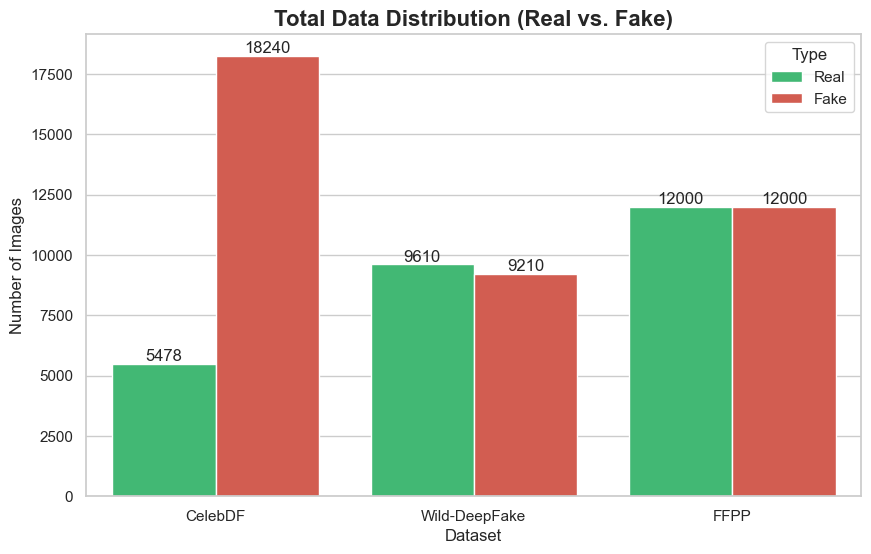

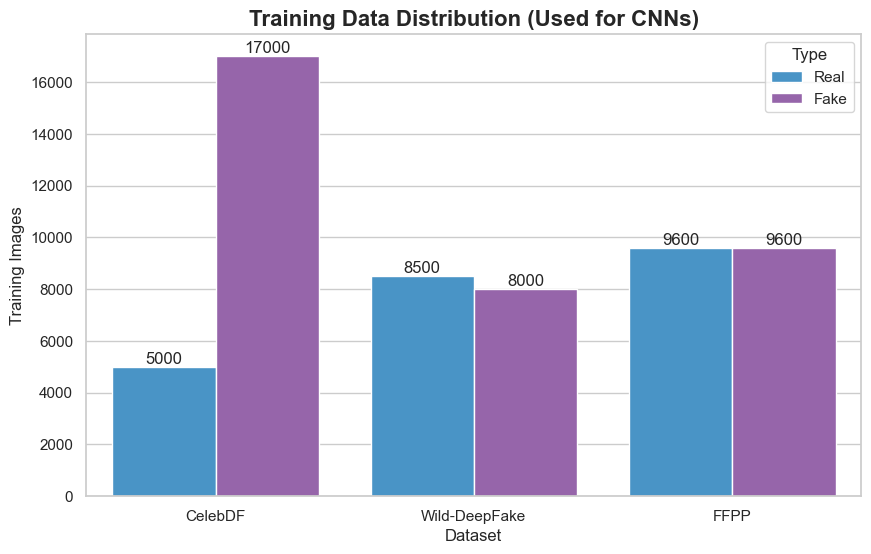

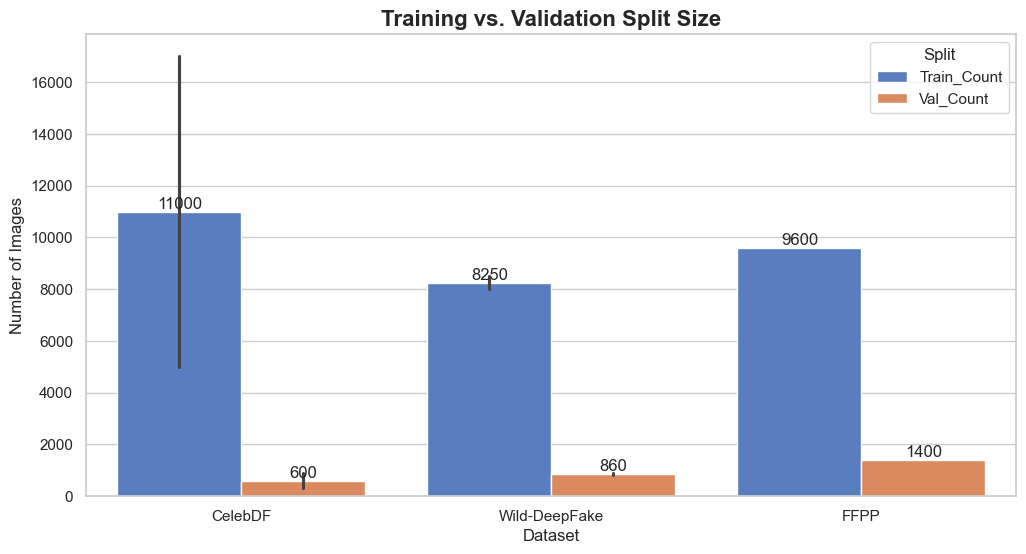

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Define the data based on your constants
data = {
    'Dataset': ['CelebDF', 'CelebDF', 'Wild-DeepFake', 'Wild-DeepFake', 'FFPP', 'FFPP'],
    'Type': ['Real', 'Fake', 'Real', 'Fake', 'Real', 'Fake'],
    'Train_Count': [5000, 17000, 8500, 8000, 9600, 9600],
    'Val_Count': [300, 900, 810, 910, 1400, 1400],
    'Test_Count': [178, 340, 300, 300, 1000, 1000]
}

df = pd.DataFrame(data)

# Calculate Totals
df['Total'] = df['Train_Count'] + df['Val_Count'] + df['Test_Count']

# Set style
sns.set_theme(style="whitegrid")

# --- Graph 1: Total Real vs. Fake Data per Dataset ---
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Dataset', y='Total', hue='Type', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Total Data Distribution (Real vs. Fake)', fontsize=16, fontweight='bold')
plt.ylabel('Number of Images')
for container in ax.containers:
    ax.bar_label(container)
plt.savefig('Total_Data_Distribution.png', dpi=300)
plt.show()

# --- Graph 2: Training Data Used for Models ---
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Dataset', y='Train_Count', hue='Type', data=df, palette=['#3498db', '#9b59b6'])
plt.title('Training Data Distribution (Used for CNNs)', fontsize=16, fontweight='bold')
plt.ylabel('Training Images')
for container in ax.containers:
    ax.bar_label(container)
plt.savefig('Training_Data_Distribution.png', dpi=300)
plt.show()

# --- Graph 3: Train vs. Validation Split Comparison ---
# Reshape for easy plotting
melted_df = df.melt(id_vars=['Dataset', 'Type'], value_vars=['Train_Count', 'Val_Count'], 
                    var_name='Split', value_name='Count')

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Dataset', y='Count', hue='Split', data=melted_df, palette='muted')
plt.title('Training vs. Validation Split Size', fontsize=16, fontweight='bold')
plt.ylabel('Number of Images')
for container in ax.containers:
    ax.bar_label(container)
plt.savefig('Train_vs_Val_Split.png', dpi=300)
plt.show()